In [11]:
!pip install langchain-openai
!pip install langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 3.4 MB/s eta 0:00:00


In [13]:
import os
from dotenv import load_dotenv
load_dotenv()


from langchain.chat_models import init_chat_model

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")

In [14]:
llm=init_chat_model("openai:gpt-4o-mini")
llm

ChatOpenAI(profile={'name': 'GPT-4o mini', 'release_date': '2024-07-18', 'last_updated': '2024-07-18', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x7b14913cd5b0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x7b1459966180>, root_client=<openai.OpenAI object at 0x7b145ae7bec0>, root_async_client=<openai.AsyncOpenAI object at 0x7b14913cd970>, model_name='gpt-4o-mini', model_kwargs={}, openai_api_key=SecretStr('**********'

In [15]:
from typing import Annotated

from langchain_core.tools import tool
from langchain_community.tools.wikipedia.tool import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.document_loaders import TextLoader
from langchain_community.vectorstores import FAISS




---


# ***Sequential\***


---



In [16]:
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.prebuilt import create_react_agent
from langgraph.graph import MessagesState, END
from langgraph.types import Command

import operator
from typing import Annotated, Sequence, TypedDict
from langchain_core.messages import BaseMessage, HumanMessage

class AgentState(TypedDict):
    # The operator.add allows nodes to append messages to the history
    messages: Annotated[Sequence[BaseMessage], operator.add]

In [17]:
def make_system_prompt(suffix: str) -> str:
    return (
        "You are a helpful AI assistant, collaborating with other assistants."
        " Use the provided tools to progress towards answering the question."
        " If you are unable to fully answer, that's OK, another assistant with different tools "
        " will help where you left off. Execute what you can to make progress."
        " If you or any of the other assistants have the final answer or deliverable,"
        " prefix your response with FINAL ANSWER so the team knows to stop."
        f"\n{suffix}"
    )

In [18]:
def teacher_node(state: AgentState):
    # In a real scenario, the teacher might look up a DB.
    # Here, we simulate the teacher sending the scores.
    message = HumanMessage(
        content="Here are the scores for the three students: Alice: 85, Bob: 92, Charlie: 78.",
        name="Teacher"
    )
    return {"messages": [message]}

def principal_node(state: AgentState):
    # We pass the system prompt you created
    suffix = ("You are school principal and your work is to do an average of the students test scores. "
              "Prefix your response with FINAL ANSWER.")
    system_prompt = make_system_prompt(suffix)

    # The Principal looks at the last message (from the teacher)
    response = llm.invoke([{"role": "system", "content": system_prompt}] + state["messages"])
    return {"messages": [response]}

In [19]:
from langgraph.graph import StateGraph, END

# Initialize the graph
workflow = StateGraph(AgentState)

# Add our two actors
workflow.add_node("teacher", teacher_node)
workflow.add_node("principal", principal_node)

# Define the flow: Start -> Teacher -> Principal -> End
workflow.set_entry_point("teacher")
workflow.add_edge("teacher", "principal")
workflow.add_edge("principal", END)

# Compile the graph
app = workflow.compile()

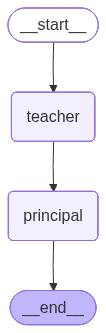

In [20]:
app


In [21]:
inputs = {"messages": [HumanMessage(content="Begin the school grading process.")]}
for output in app.stream(inputs):
    for key, value in output.items():
        print(f"Output from node '{key}':")
        print(value["messages"][-1].content)
        print("---")

Output from node 'teacher':
Here are the scores for the three students: Alice: 85, Bob: 92, Charlie: 78.
---
Output from node 'principal':
To calculate the average of the students' test scores, I will add the scores together and then divide by the number of students.

The total score is:
85 (Alice) + 92 (Bob) + 78 (Charlie) = 255

Now, divide by the number of students (3):
255 / 3 = 85

FINAL ANSWER: The average test score for the students is 85.
---




---


# ***Heirarichal (one supervisor)***


---



# **School** A

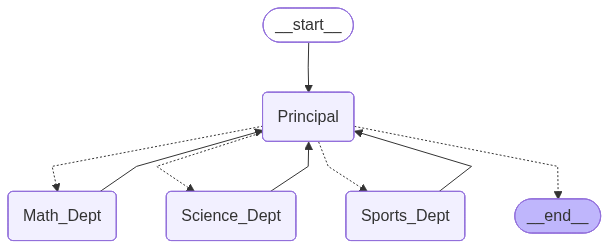

In [22]:
import operator
from typing import Annotated, Sequence, TypedDict, Literal
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph import StateGraph, START, END

# --- 1. STATE DEFINITION ---
def merge_dicts_a(existing: dict, new: dict) -> dict:
    return {**existing, **new}

class SchoolState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    averages: Annotated[dict, merge_dicts_a]
    school_results: Annotated[dict, merge_dicts_a]

# --- 2. NODE FUNCTIONS ---
def math_teacher_node(state: SchoolState):
    scores = [80, 90, 100]
    avg = sum(scores) / len(scores)
    return {
        "messages": [HumanMessage(content=f"Math average is {avg}", name="Math_Teacher")],
        "averages": {"math": avg}
    }

def science_teacher_node(state: SchoolState):
    scores = [70, 75, 80]
    avg = sum(scores) / len(scores)
    return {
        "messages": [HumanMessage(content=f"Science average is {avg}", name="Science_Teacher")],
        "averages": {"science": avg}
    }

def sports_teacher_node(state: SchoolState):
    scores = [95, 100, 90]
    avg = sum(scores) / len(scores) # Fixed the parenthesis here
    return {
        "messages": [HumanMessage(content=f"Sports average is {avg}", name="Sports_Teacher")],
        "averages": {"sports": avg}
    }

def principal_node(state: SchoolState):
    # The Principal only calculates the final total if all data is present
    if len(state["averages"]) == 3:
        all_avgs = state["averages"].values()
        final_avg = sum(all_avgs) / len(all_avgs)
        return {"messages": [AIMessage(content=f"FINAL ANSWER: The school average is {final_avg:.2f}")],
                "school_results": {"School_A": final_avg}}
    return {"messages": [AIMessage(content="Principal is checking the reports...")]}

# --- 3. ROUTING LOGIC ---
def principal_router(state: SchoolState) -> Literal["Math_Dept", "Science_Dept", "Sports_Dept", "__end__"]:
    if "math" not in state["averages"]:
        return "Math_Dept"
    if "science" not in state["averages"]:
        return "Science_Dept"
    if "sports" not in state["averages"]:
        return "Sports_Dept"
    return "__end__"

# --- 4. GRAPH CONSTRUCTION ---
builder = StateGraph(SchoolState)
builder.add_node("Math_Dept", math_teacher_node)
builder.add_node("Science_Dept", science_teacher_node)
builder.add_node("Sports_Dept", sports_teacher_node)
builder.add_node("Principal", principal_node)

builder.add_edge(START, "Principal")
builder.add_conditional_edges(
    "Principal",
    principal_router,
    {
        "Math_Dept": "Math_Dept",
        "Science_Dept": "Science_Dept",
        "Sports_Dept": "Sports_Dept",
        "__end__": END
    }
)

builder.add_edge("Math_Dept", "Principal")
builder.add_edge("Science_Dept", "Principal")
builder.add_edge("Sports_Dept", "Principal")

school_a_graph = builder.compile()

school_a_graph



In [23]:

if __name__ == "__main__":
    initial_input = {"messages": [], "averages": {}}

    print("--- Starting Supervisor-Led Meeting ---\n")
    for chunk in school_a_graph.stream(initial_input, stream_mode="updates"):
        for node_name, update in chunk.items():
            print(f"📍 Node: {node_name}")
            if "messages" in update:
                print(f"   {update['messages'][-1].content}")
            print("-" * 30)

--- Starting Supervisor-Led Meeting ---

📍 Node: Principal
   Principal is checking the reports...
------------------------------
📍 Node: Math_Dept
   Math average is 90.0
------------------------------
📍 Node: Principal
   Principal is checking the reports...
------------------------------
📍 Node: Science_Dept
   Science average is 75.0
------------------------------
📍 Node: Principal
   Principal is checking the reports...
------------------------------
📍 Node: Sports_Dept
   Sports average is 95.0
------------------------------
📍 Node: Principal
   FINAL ANSWER: The school average is 86.67
------------------------------


# **School** B


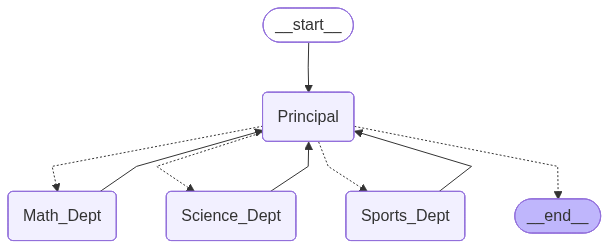

In [24]:
import operator
from typing import Annotated, Sequence, TypedDict, Literal
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph import StateGraph, START, END

# --- 1. STATE DEFINITION ---
def merge_dicts_b(existing: dict, new: dict) -> dict:
    return {**existing, **new}

class SchoolState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    averages: Annotated[dict, merge_dicts_b]
    school_results: Annotated[dict, merge_dicts_b]

# --- 2. NODE FUNCTIONS ---
def math_teacher_node(state: SchoolState):
    scores = [80, 90, 70]
    avg = sum(scores) / len(scores)
    return {
        "messages": [HumanMessage(content=f"Math average is {avg}", name="Math_Teacher")],
        "averages": {"math": avg}
    }

def science_teacher_node(state: SchoolState):
    scores = [70, 60, 80]
    avg = sum(scores) / len(scores)
    return {
        "messages": [HumanMessage(content=f"Science average is {avg}", name="Science_Teacher")],
        "averages": {"science": avg}
    }

def sports_teacher_node(state: SchoolState):
    scores = [95, 79, 90]
    avg = sum(scores) / len(scores) # Fixed the parenthesis here
    return {
        "messages": [HumanMessage(content=f"Sports average is {avg}", name="Sports_Teacher")],
        "averages": {"sports": avg}
    }

def principal_node(state: SchoolState):
    # The Principal only calculates the final total if all data is present
    if len(state["averages"]) == 3:
        all_avgs = state["averages"].values()
        final_avg = sum(all_avgs) / len(all_avgs)
        return {"messages": [AIMessage(content=f"FINAL ANSWER: The school average is {final_avg:.2f}")],
                "school_results": {"School_B": final_avg}}
    return {"messages": [AIMessage(content="Principal is checking the reports...")]}

# --- 3. ROUTING LOGIC ---
def principal_router(state: SchoolState) -> Literal["Math_Dept", "Science_Dept", "Sports_Dept", "__end__"]:
    if "math" not in state["averages"]:
        return "Math_Dept"
    if "science" not in state["averages"]:
        return "Science_Dept"
    if "sports" not in state["averages"]:
        return "Sports_Dept"
    return "__end__"

# --- 4. GRAPH CONSTRUCTION ---
builder = StateGraph(SchoolState)
builder.add_node("Math_Dept", math_teacher_node)
builder.add_node("Science_Dept", science_teacher_node)
builder.add_node("Sports_Dept", sports_teacher_node)
builder.add_node("Principal", principal_node)

builder.add_edge(START, "Principal")
builder.add_conditional_edges(
    "Principal",
    principal_router,
    {
        "Math_Dept": "Math_Dept",
        "Science_Dept": "Science_Dept",
        "Sports_Dept": "Sports_Dept",
        "__end__": END
    }
)

builder.add_edge("Math_Dept", "Principal")
builder.add_edge("Science_Dept", "Principal")
builder.add_edge("Sports_Dept", "Principal")

school_b_graph = builder.compile()

school_b_graph



In [25]:

if __name__ == "__main__":
    initial_input = {"messages": [], "averages": {}}

    print("--- Starting Supervisor-Led Meeting ---\n")
    for chunk in school_b_graph.stream(initial_input, stream_mode="updates"):
        for node_name, update in chunk.items():
            print(f"📍 Node: {node_name}")
            if "messages" in update:
                print(f"   {update['messages'][-1].content}")
            print("-" * 30)



--- Starting Supervisor-Led Meeting ---

📍 Node: Principal
   Principal is checking the reports...
------------------------------
📍 Node: Math_Dept
   Math average is 80.0
------------------------------
📍 Node: Principal
   Principal is checking the reports...
------------------------------
📍 Node: Science_Dept
   Science average is 70.0
------------------------------
📍 Node: Principal
   Principal is checking the reports...
------------------------------
📍 Node: Sports_Dept
   Sports average is 88.0
------------------------------
📍 Node: Principal
   FINAL ANSWER: The school average is 79.33
------------------------------


In [26]:
SchoolState

__main__.SchoolState



---



---



# Super Hierarichal - Supervisor of supervisors (one way)


---



---



In [27]:

def merge_dicts(existing: dict, new: dict) -> dict:
    return {**existing, **new}

class DirectorState(TypedDict):
    # A dictionary to store { "School_A": 85.5, "School_B": 88.2 }
    school_results: Annotated[dict, merge_dicts]
    messages: Annotated[Sequence[BaseMessage], operator.add]

In [28]:
def director_node(state: DirectorState):
    results = state["school_results"]
    print(results)

    # Ensure both schools have reported
    if len(results) < 2:
        return {"messages": [AIMessage(content="Waiting for all schools to report...")]}

    # Determine the winner
    winner = max(results, key=results.get)
    win_score = results[winner]
    print(win_score)

    return {
        "messages": [AIMessage(content=f"🏆 WINNER: {winner} with an average of {win_score:.2f}!")]
    }

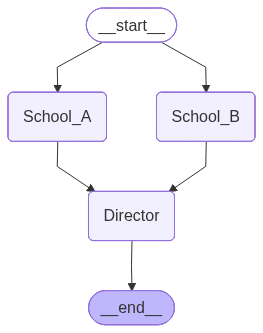

In [29]:
# Create the Super-Graph
director_builder = StateGraph(DirectorState)

# 1. Add the Schools as Nodes (using the graph you already built)
# We assume 'school_a_graph' and 'school_b_graph' are compiled instances
director_builder.add_node("School_A", school_a_graph)
director_builder.add_node("School_B", school_b_graph)

# 2. Add the Director
director_builder.add_node("Director", director_node)

# 3. Define the Flow
# Start both schools in parallel
director_builder.add_edge(START, "School_A")
director_builder.add_edge(START, "School_B")

# Both report to the Director once they finish their internal loops
director_builder.add_edge("School_A", "Director")
director_builder.add_edge("School_B", "Director")

director_builder.add_edge("Director", END)

multi_school_system_v1 = director_builder.compile()
multi_school_system_v1

In [30]:
if __name__ == "__main__":
    # We pass 'school_id' so the sub-graphs know who they are
    # Using 'stream' to watch both schools work in parallel
    initial_input = {"averages": {}, "messages": []}

    print("--- Director starting the Multi-School Competition ---\n")

    # We use a configuration-like trick to pass different IDs to the same node logic
    # In a real app, you'd wrap the school_compiled in a function to set the ID
    for chunk in multi_school_system_v1.stream(
        {"averages": {}, "messages": []},
        # Note: In reality, you'd use 'config' to distinguish sub-graphs
        stream_mode="updates"
    ):
        for node_name, update in chunk.items():
            print(f"📍 Node {node_name} finished.")
            if "messages" in update:
                print(f"   Message: {update['messages'][-1].content}")

--- Director starting the Multi-School Competition ---

📍 Node School_A finished.
   Message: FINAL ANSWER: The school average is 86.67
📍 Node School_B finished.
   Message: FINAL ANSWER: The school average is 79.33
{'School_A': 86.66666666666667, 'School_B': 79.33333333333333}
86.66666666666667
📍 Node Director finished.
   Message: 🏆 WINNER: School_A with an average of 86.67!




---



---




# Super Hierarichal - Supervisor of supervisors (Two way)


---



---



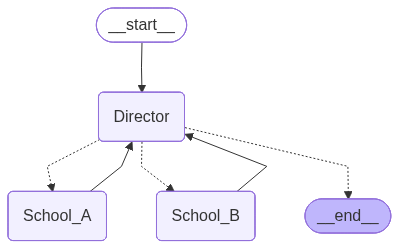

In [31]:
import operator
from typing import Annotated, Sequence, TypedDict, Union
from langchain_core.messages import BaseMessage, AIMessage
from langgraph.graph import StateGraph, START, END

# --- 1. State and Reducer ---
def merge_dicts(existing: dict, new: dict) -> dict:
    # Merges new results into the existing dictionary
    return {**existing, **new}

class DirectorState(TypedDict):
    school_results: Annotated[dict, merge_dicts]
    messages: Annotated[Sequence[BaseMessage], operator.add]

# --- 2. Node Logic ---
def director_node(state: DirectorState):
    results = state.get("school_results", {})

    # If both schools are in, we determine a winner
    if len(results) >= 2:
        winner = max(results, key=results.get)
        win_score = results[winner]
        return {
            "messages": [AIMessage(content=f"🏆 WINNER: {winner} with {win_score:.2f}!")]
        }

    # Otherwise, we just acknowledge we are waiting/routing
    return {"messages": [AIMessage(content="Director analyzing results...")]}

def director_router(state: DirectorState):
    results = state.get("school_results", {})

    # Logic: If a school hasn't reported, go to that school
    if "School_A" not in results:
        return "School_A"
    if "School_B" not in results:
        return "School_B"

    # If both have reported, we are done
    return "__end__"

# --- 3. Build the Graph ---
director_builder = StateGraph(DirectorState)

# Add your nodes
# (Using placeholder functions here since school_a_graph would be your compiled graph)
director_builder.add_node("School_A", school_a_graph)
director_builder.add_node("School_B", school_b_graph)
director_builder.add_node("Director", director_node)

# --- 4. Define the Flow ---

# START -> Director
director_builder.add_edge(START, "Director")

# Director -> Router -> (School A, School B, or END)
director_builder.add_conditional_edges(
    "Director",
    director_router,
    {
        "School_A": "School_A",
        "School_B": "School_B",
        "__end__": END
    }
)

# Schools always report back to the Director to re-evaluate the state
director_builder.add_edge("School_A", "Director")
director_builder.add_edge("School_B", "Director")

# Compile
multi_school_system_v2 = director_builder.compile()

multi_school_system_v2

In [32]:
# --- 5. Execution ---
if __name__ == "__main__":
    # We start with an empty result set
    initial_input = {"school_results": {}, "messages": []}

    print("--- Starting Multi-School System from Director ---\n")

    for chunk in multi_school_system_v2.stream(initial_input, stream_mode="updates"):
        for node_name, update in chunk.items():
            print(f"📍 Node {node_name} finished.")
            if "messages" in update:
                print(f"   Message: {update['messages'][-1].content}")

--- Starting Multi-School System from Director ---

📍 Node Director finished.
   Message: Director analyzing results...
📍 Node School_A finished.
   Message: FINAL ANSWER: The school average is 86.67
📍 Node Director finished.
   Message: Director analyzing results...
📍 Node School_B finished.
   Message: FINAL ANSWER: The school average is 79.33
📍 Node Director finished.
   Message: 🏆 WINNER: School_A with 86.67!


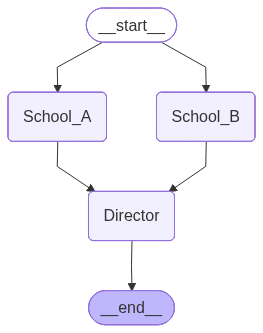

*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-


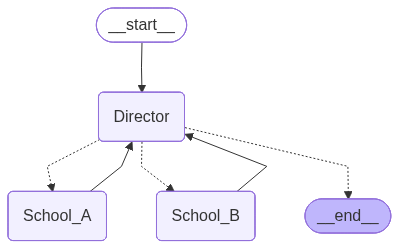

In [33]:
from IPython.display import Image, display

# This will show you exactly which arrows are solid (edges)
# and which are dashed (conditional edges)
display(Image(multi_school_system_v1.get_graph().draw_mermaid_png()))
print("*-"*100)
display(Image(multi_school_system_v2.get_graph().draw_mermaid_png()))


---



---



# Super Hierarichal - Supervisor of supervisors (Two way)

Uses command function from langraph which enables agent calling within| the node itself without using a dedicated router function i.e conditional edges



---



---


In [34]:
from typing import Annotated, Sequence, TypedDict
from langchain_core.messages import BaseMessage, AIMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command  # Required for the new syntax
import operator

# --- 1. State ---
def merge_dicts(existing: dict, new: dict) -> dict:
    return {**existing, **new}

class DirectorState(TypedDict):
    school_results: Annotated[dict, merge_dicts]
    messages: Annotated[Sequence[BaseMessage], operator.add]

# --- 2. The Director Node (Logic + Routing combined) ---
def director_node(state: DirectorState) -> Command:
    results = state.get("school_results", {})

    # 1. Check if School A needs to run
    if "School_A" not in results:
        print("--- Director: Sending to School A ---")
        return Command(
            goto="School_A",
            update={"messages": [AIMessage(content="Director: School A, your turn.")]}
        )

    # 2. Check if School B needs to run
    if "School_B" not in results:
        print("--- Director: Sending to School B ---")
        return Command(
            goto="School_B",
            update={"messages": [AIMessage(content="Director: School B, your turn.")]}
        )

    # 3. If both are done, finish the graph
    winner = max(results, key=results.get)
    return Command(
        goto=END,
        update={"messages": [AIMessage(content=f"🏆 WINNER: {winner} is the champion!")]}
    )

# --- 3. Build the Graph ---
builder = StateGraph(DirectorState)

# Add Nodes
builder.add_node("Director", director_node)
builder.add_node("School_A", school_a_graph) # Your compiled school graph
builder.add_node("School_B", school_b_graph) # Your compiled school graph

# Define the Loop
builder.add_edge(START, "Director")
builder.add_edge("School_A", "Director")
builder.add_edge("School_B", "Director")

# Notice: No 'add_conditional_edges' needed anymore!
multi_school_system_v3 = builder.compile()

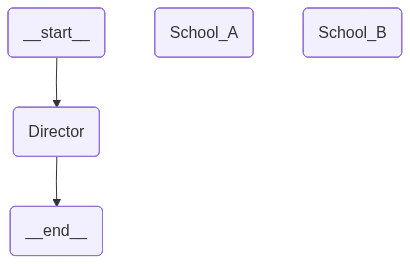

In [35]:
multi_school_system_v3

In [36]:
# --- 5. Execution ---
if __name__ == "__main__":
    # We start with an empty result set
    initial_input = {"school_results": {}, "messages": []}

    print("--- Starting Multi-School System from Director ---\n")

    for chunk in multi_school_system_v3.stream(initial_input, stream_mode="updates"):
        for node_name, update in chunk.items():
            print(f"📍 Node {node_name} finished.")
            if "messages" in update:
                print(f"   Message: {update['messages'][-1].content}")

--- Starting Multi-School System from Director ---

--- Director: Sending to School A ---
📍 Node Director finished.
   Message: Director: School A, your turn.
📍 Node School_A finished.
   Message: FINAL ANSWER: The school average is 86.67
--- Director: Sending to School B ---
📍 Node Director finished.
   Message: Director: School B, your turn.
📍 Node School_B finished.
   Message: FINAL ANSWER: The school average is 79.33
📍 Node Director finished.
   Message: 🏆 WINNER: School_A is the champion!
